# Toy System — 3D Version

## System Definition

Let  

$$
E_R = \{ x \in \mathbb{R}^3 : \|x\| \le R \}
$$  

and let $\nu$ be a probability measure supported on $E_1$ (the regime).  
We consider the process $(X_t)_{t \ge 0}$  evolving in $E_2$ with **reinsertion** occurring whenever the system’s radius exceeds $2$.
- **Flow** For $x \in \mathbb{R}^3$, define the deterministic flow  

$$
\dot{x} = f(x) = x, \qquad 
\phi(t, x) = x e^{t}.
$$

Each component satisfies $\dot{x}_i = x_i$, and therefore the norm evolves as  

$$
\|\phi(t, x)\| = \|x\| e^{t}.
$$


- **Boundary Hitting Time** The time it takes for a point $x$ to reach the boundary of radius $1$ is  

$$
\tau(x)
= \inf \{ t > 0 : \|\phi(t, x)\| = 1 \}
= \ln \!\left( \frac{1}{\|x\|} \right), \qquad x \ne 0,
$$  

and $\tau(0) = +\infty$.  

- **Reinsertion Rule** Whenever the process transgresses the boundary $\partial E_2$ it is **instantaneously reset** to a random point drawn from the reinsertion measure $\nu$, independently of the past:

$$
X_t \sim \nu.
$$

In [61]:
import numpy as np
import cdv_utils
import matplotlib.pyplot as plt
import importlib
from scipy import sparse
importlib.reload(cdv_utils)

<module 'cdv_utils' from '/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py'>

In [62]:
from cdv_utils import (plot_lifetime_distributions_lines, diffusion_maps_matrix, calculate_escape_times,
                       expected_escape_times_from_TO, add_scaled_top_axis, spy_col)

In [2]:
dt = 1e-3
save_every = 1

In [3]:
import math
import numpy as np
from numba import njit, prange
from typing import Optional, Callable

# --- Numba kernel (parallel over trajectories) for 3D states ---


@njit(parallel=True, cache=True)
def _simulate_numba_parallel_sigma_arr_3d(dt, sigma_arr, x0,
                                          normals, reset_samples, save_every):
    """
    Numba-parallel kernel for 3D trajectories.
    normals, reset_samples: shape (n_steps, n_paths, 3)
    sigma_arr: shape (n_paths,)
    Returns saved states shape (n_saves, n_paths, 3) dtype=float32
    """
    n_steps_local, n_paths, _ = normals.shape
    max_saves = (n_steps_local // save_every) + 1
    saved = np.empty((max_saves, n_paths, 3), dtype=np.float32)

    phi = math.exp(dt)
    var = (math.exp(2.0 * dt) - 1.0) / 2.0
    sqrt_var = math.sqrt(var)

    for p in prange(n_paths):
        # initialize state x as a local 3-vector
        x0_0 = x0[0]
        x0_1 = x0[1]
        x0_2 = x0[2]
        x0_0 = np.float32(x0_0)
        x0_1 = np.float32(x0_1)
        x0_2 = np.float32(x0_2)

        x0_local0 = x0_0
        x0_local1 = x0_1
        x0_local2 = x0_2

        save_idx = 0
        saved[save_idx, p, 0] = x0_local0
        saved[save_idx, p, 1] = x0_local1
        saved[save_idx, p, 2] = x0_local2
        save_idx += 1

        s = float(sigma_arr[p])
        for i in range(n_steps_local):
            # compute squared norm
            norm2 = x0_local0 * x0_local0 + x0_local1 * x0_local1 + x0_local2 * x0_local2

            # restart if outside ball of radius 2 (i.e., norm^2 >= 4)
            if norm2 >= 4.0:
                # reset_samples shape: (n_steps, n_paths, 3)
                x0_local0 = reset_samples[i, p, 0]
                x0_local1 = reset_samples[i, p, 1]
                x0_local2 = reset_samples[i, p, 2]
            else:
                # exact linear step for each component + additive noise
                # normals[i, p, k] ~ N(0,1)
                x0_local0 = x0_local0 * phi + s * sqrt_var * normals[i, p, 0]
                x0_local1 = x0_local1 * phi + s * sqrt_var * normals[i, p, 1]
                x0_local2 = x0_local2 * phi + s * sqrt_var * normals[i, p, 2]

            if ((i + 1) % save_every) == 0:
                saved[save_idx, p, 0] = x0_local0
                saved[save_idx, p, 1] = x0_local1
                saved[save_idx, p, 2] = x0_local2
                save_idx += 1

    return saved


def simulate_trajectories_per_sigma_3d(
        sigmas,
        dt: float,
        n_steps: int,
        reset_sampler: Callable[[np.random.Generator, tuple], np.ndarray],
        rng: Optional[np.random.Generator] = None,
        save_every: int = 1,
        x0: Optional[np.ndarray] = None,
        dtype=np.float32):
    """
    Simulate one 3D continuous trajectory per sigma value in `sigmas`.

    Args
      sigmas: scalar or 1-D array-like of sigma values (if scalar it will be converted to length-1 array)
      dt: time step
      n_steps: number of integration steps (trajectory length)
      reset_sampler: vectorized callable reset_sampler(rng, size) -> array shaped `size`
                     For 3D this should return shape (n_steps, n_paths, 3) containing **vectors** to reset to.
      rng: np.random.Generator (if None a new generator is created)
      save_every: save states every `save_every` steps (1 => save every step)
      x0: initial condition (array-like of length 3). If None defaults to [0.1, 0.0, 0.0]
      dtype: np.float32 recommended; set to np.float64 if you need double precision

    Returns:
      times: 1D float array of saved times (length n_saves)
      saved_states: 3D array shape (n_saves, n_paths, 3), column j corresponds to sigmas[j]
      sigma_arr: 1D array of sigma values (dtype)
    """
    if rng is None:
        rng = np.random.default_rng()

    sigmas = np.asarray(sigmas, dtype=float)
    if sigmas.ndim == 0:
        sigmas = np.asarray([sigmas], dtype=float)
    n_paths = sigmas.shape[0]
    n_saves = (n_steps // save_every) + 1

    if x0 is None:
        x0 = np.array([0.1, 0.0, 0.0], dtype=dtype)
    else:
        x0 = np.asarray(x0, dtype=dtype)
        if x0.shape != (3,):
            raise ValueError(
                "x0 must be an array-like of length 3 for 3D simulation")

    # Pre-sample normals and reset samples (shape: n_steps x n_paths x 3)
    normals = rng.normal(loc=0.0, scale=1.0, size=(
        n_steps, n_paths, 3)).astype(dtype, copy=False)
    reset_samples = reset_sampler(rng, size=(
        n_steps, n_paths, 3)).astype(dtype, copy=False)

    saved_states = _simulate_numba_parallel_sigma_arr_3d(float(dt), sigmas.astype(dtype),
                                                         x0.astype(dtype),
                                                         normals, reset_samples,
                                                         int(save_every))
    times = np.arange(n_saves, dtype=float) * (save_every * dt)
    return times, saved_states, sigmas


# --- Example vectorized reset samplers for 3D ---


def uniform_reset_sampler_vectorized_3d(rng: np.random.Generator, size, low=-0.1, high=0.1):
    """
    Returns reset vectors with independent components drawn uniformly on [low, high).
    size: tuple (n_steps, n_paths, 3)
    """
    return rng.uniform(low, high, size=size)


def uniform_in_ball_reset_sampler_vectorized(rng: np.random.Generator, size, radius=0.1):
    """
    Returns reset vectors uniformly distributed in the 3D ball of given radius.
    Uses rejection sampling; size is (n_steps, n_paths, 3) and the function returns that shape.
    For moderate radius and typical sizes this is fine; for extreme performance consider direct radial sampling.
    """
    n_steps, n_paths, _ = size
    out = np.empty(size, dtype=np.float64)
    for i in range(n_steps):
        for j in range(n_paths):
            # rejection sampling per vector
            while True:
                v = rng.uniform(-radius, radius, size=3)
                if v[0]*v[0] + v[1]*v[1] + v[2]*v[2] <= radius*radius:
                    out[i, j, :] = v
                    break
    return out

In [4]:
rng = np.random.default_rng(12345)
times, states, sigma_arr = simulate_trajectories_per_sigma_3d(
    sigmas=np.array([0.0], dtype=np.float32),
    dt=dt,
    n_steps=100000 - 1,
    reset_sampler=uniform_reset_sampler_vectorized_3d,
    rng=rng,
    save_every=save_every,
    x0=np.array([0.1, 0.1, 0.1],),
    dtype=np.float32
)
reset_times_per_path = [
    times[np.linalg.norm(states[:, j, :], axis=1) > 2.0]
    for j in range(states.shape[1])
]

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional


def plot_trajectory_with_reinsertions_3d(ax: Optional[plt.Axes],
                                         times: np.ndarray,
                                         states: np.ndarray,
                                         jump_times: np.ndarray,
                                         path_index: int = 0,
                                         title: str = "3D trajectory components with reinsertion (|x|≥2)",
                                         show_ylabel: bool = True,
                                         show_xlabel: bool = True) -> plt.Axes:
    """
    Plot a single 3D trajectory's three components on one axes and draw reinsertion rug markers.

    Parameters
    ----------
    ax : Optional[plt.Axes]
        Matplotlib axes to draw on. If None, a new figure/axes is created.
    times : 1D array_like
        Saved times (length n_saves).
    states : array_like
        Trajectory states. Accepted shapes:
          - (n_saves, 3)          : single 3D trajectory
          - (n_saves, n_paths, 3) : many trajectories; `path_index` selects which path to plot
    jump_times : 1D array_like
        Times of reinsertion events (rug markers).
    path_index : int
        If `states` has shape (n_saves, n_paths, 3), choose this path (default 0).
    title : str
        Plot title.
    show_ylabel, show_xlabel : bool
        Whether to show axis labels.

    Returns
    -------
    ax : plt.Axes
        The axes with the plot.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 4))

    times = np.asarray(times)
    jump_times = np.asarray(jump_times)

    states = np.asarray(states)
    if states.ndim == 3:
        # choose the requested path index
        if path_index < 0 or path_index >= states.shape[1]:
            raise IndexError(
                "path_index out of range for states with shape (n_saves, n_paths, 3)")
        traj = states[:, path_index, :]   # shape (n_saves, 3)
    elif states.ndim == 2 and states.shape[1] == 3:
        traj = states  # shape (n_saves, 3)
    else:
        raise ValueError(
            "states must have shape (n_saves, 3) or (n_saves, n_paths, 3)")

    # Plot the three components with distinct colours and labels
    comp_labels = ["x₁(t)", "x₂(t)", "x₃(t)"]
    colors = ["C0", "C1", "C2"]
    for k in range(3):
        ax.plot(times, traj[:, k], lw=0.9,
                label=comp_labels[k], color=colors[k])

    # Optional reference horizontal lines (analogous to 1D case)
    ax.axhline(1.0, ls="--", alpha=0.5)
    ax.axhline(-1.0, ls="--", alpha=0.5)
    ax.axhline(2.0, ls="--", alpha=0.5, color="grey")
    ax.axhline(-2.0, ls="--", alpha=0.5, color="grey")

    # rug markers for reinsertion times: place them slightly below the plotted data
    n_reinserts = int(jump_times.size)
    if n_reinserts > 0:
        ymin = np.min(traj)
        ymax = np.max(traj)
        yrange = ymax - ymin if (ymax > ymin) else 1.0
        rug_y = np.full_like(jump_times, ymin - 0.08 * yrange)
        ax.plot(jump_times, rug_y, linestyle='None', marker='|', markersize=8,
                label='reinsertions', color='k', zorder=5)

    # Annotate with total reinsertion count
    ax.text(
        0.02, 0.55,
        f"reinsertions: {n_reinserts}",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

    # Labels / title
    if show_xlabel:
        ax.set_xlabel("time")
    if show_ylabel:
        ax.set_ylabel("components")
    ax.set_title(title)

    ax.legend(loc='upper right', fontsize='small')
    # set reasonable ylim with small margin
    ymin = np.min(traj)
    ymax = np.max(traj)
    margin = 0.08 * (ymax - ymin if ymax > ymin else 1.0)
    ax.set_ylim(ymin - margin, ymax + margin)

    return ax

<Axes: title={'center': '3D trajectory components with reinsertion (|x|≥2)'}, xlabel='time', ylabel='components'>

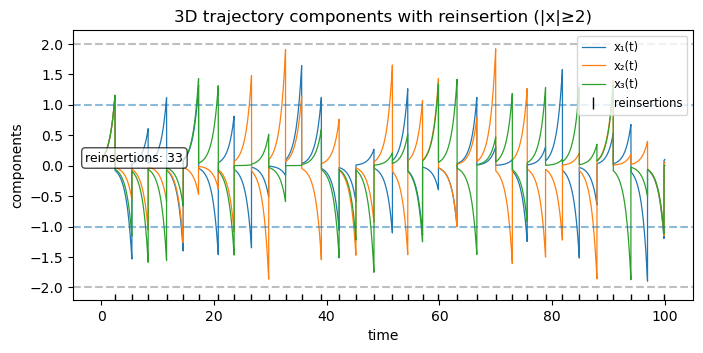

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))

plot_trajectory_with_reinsertions_3d(
    ax, times, states, reset_times_per_path[0])

In [7]:
sigmas = np.linspace(0.0, 0.5, 101, dtype=np.float32)
# 68 seconds
rng = np.random.default_rng(12345)
times, states, sigma_arr = simulate_trajectories_per_sigma_3d(
    sigmas=sigmas,
    dt=dt,
    n_steps=int(1e7) - 1,
    reset_sampler=uniform_reset_sampler_vectorized_3d,
    rng=rng,
    save_every=save_every,
    x0=np.array([0.1, 0.1, 0.1],),
    dtype=np.float32
)
reset_times_per_path = [
    times[np.linalg.norm(states[:, j, :], axis=1) > 2.0]
    for j in range(states.shape[1])
]

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Sequence


def plot_multiple_sigmas(times: np.ndarray,
                         states: np.ndarray,
                         sigmas: Sequence[float],
                         reset_times_per_path: Sequence[np.ndarray],
                         n_cols: int = 1,
                         figsize: tuple = (8, 3),
                         sharex: bool = True):
    """
    Create subplots showing trajectories for multiple sigma values.

    Parameters
    ----------
    times : np.ndarray
        Common time vector returned by simulate_over_sigmas.
    results_dict : dict
        Dictionary mapping sigma -> {'states', 'jump_times', 'jump_states'}.
    sigmas : Sequence[float]
        Array/list of sigma values to plot (must be keys of results_dict).
    n_cols : int, optional
        Number of subplot columns. Rows are computed automatically.
    figsize : tuple, optional
        Base figure size per row.
    sharex : bool, optional
        Whether to share x-axis among subplots.
    """
    n_sigmas = len(sigmas)
    n_rows = int(np.ceil(n_sigmas / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(figsize[0] * n_cols,
                                      figsize[1] * n_rows),
                             sharex=sharex)
    axes = np.atleast_1d(axes).flatten()

    for i, sigma in enumerate(sigmas):
        ax = axes[i]
        data = states[:, i]
        plot_trajectory_with_reinsertions_3d(
            ax=ax,
            times=times,
            states=data,
            jump_times=reset_times_per_path[i],
            title=f"σ = {sigma:.3f}",
            show_xlabel=(i >= (n_rows - 1) * n_cols),
            show_ylabel=(i % n_cols == 0)
        )

    # Hide any unused axes (if n_sigmas < n_rows * n_cols)
    for j in range(n_sigmas, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

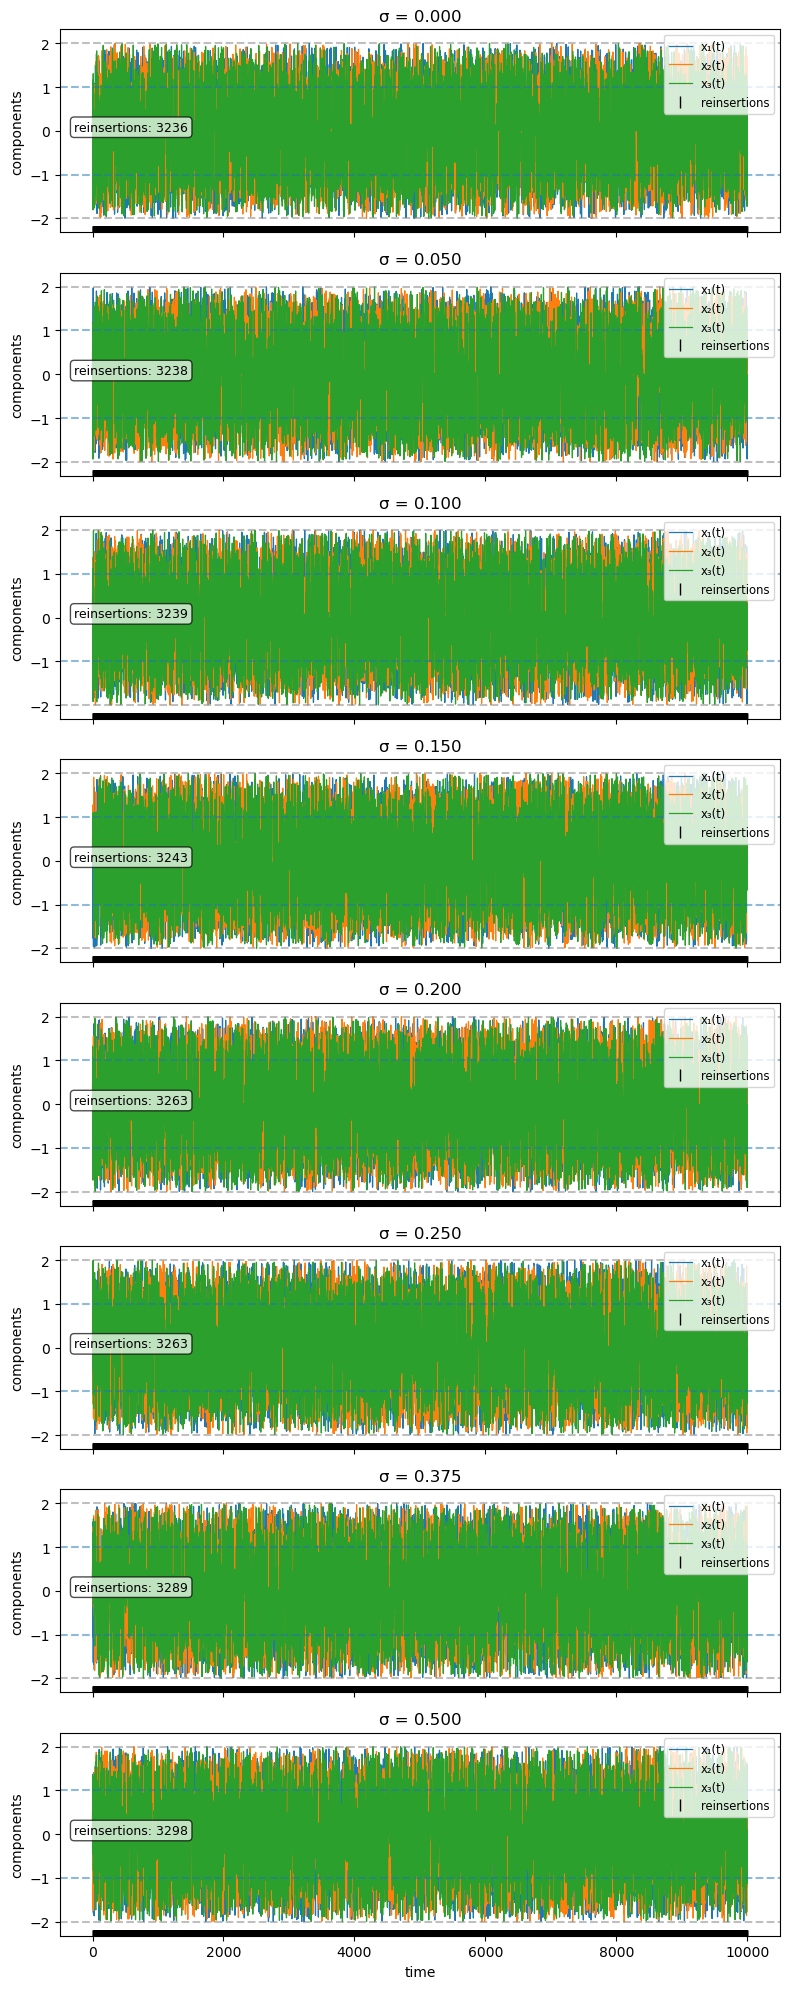

In [9]:
plot_multiple_sigmas(times, states,
                     np.quantile(sorted(sigma_arr),
                                 [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1]),
                     n_cols=1, figsize=(8, 2.5), reset_times_per_path=reset_times_per_path)

In [10]:
import numpy as np
from collections import defaultdict
from typing import Dict, List


def compute_lifetimes_per_sigma_3d(
    states: np.ndarray,
    sigma_arr: np.ndarray,
    reset_threshold: float = 2.0,
    hit_threshold: float = 1.0,
) -> Dict[float, List[int]]:
    """
    Compute lifetimes for 3D trajectories.

    Parameters
    ----------
    states : np.ndarray, shape (n_steps, n_paths, 3)
        Saved states for each path (last axis = 3 components).
    sigma_arr : np.ndarray, shape (n_paths,)
        Sigma value for each path (same column ordering as states).
    reset_threshold : float
        Radius threshold for detecting a reset (norm > reset_threshold).
    hit_threshold : float
        Radius threshold that constitutes a hit (norm >= hit_threshold).

    Returns
    -------
    dict
        { sigma_value: [lifetimes_in_saved_timesteps, ...] }
        Lifetimes are integers (number of saved timesteps after reinsertion until first hit).
        Censored reinjections (no hit before end) are skipped.
    """
    if states.ndim != 3 or states.shape[2] != 3:
        raise ValueError(
            "states must be a 3D array with shape (n_steps, n_paths, 3)")
    n_steps, n_paths, _ = states.shape
    if sigma_arr.shape[0] != n_paths:
        raise ValueError(
            "sigma_arr length must match number of paths (states.shape[1])")

    # compute radius for every saved time and path: shape (n_steps, n_paths)
    radii = np.linalg.norm(states, axis=2)

    lifetimes_per_sigma = defaultdict(list)

    for j in range(n_paths):
        col_r = radii[:, j]

        # indices where reset occurs (radius > reset_threshold)
        reset_idxs = np.nonzero(col_r > reset_threshold)[0]
        if reset_idxs.size == 0:
            continue

        # indices where hit occurs (radius >= hit_threshold)
        hit_idxs = np.nonzero(col_r >= hit_threshold)[0]
        if hit_idxs.size == 0:
            # no hits at all -> all resets are censored, skip
            continue

        # reinsertion is immediately after reset index
        reinsertion_idxs = reset_idxs + 1

        # any reinsertion beyond saved data are censored
        valid_mask = reinsertion_idxs < n_steps
        if not np.any(valid_mask):
            continue
        reinsertion_idxs = reinsertion_idxs[valid_mask]

        # For each reinsertion find the first hit index >= reinsertion using searchsorted
        pos = np.searchsorted(hit_idxs, reinsertion_idxs, side="left")

        # filter out censored (pos == len(hit_idxs))
        valid_pos_mask = pos < hit_idxs.size
        if not np.any(valid_pos_mask):
            continue

        hit_for_reset = hit_idxs[pos[valid_pos_mask]]
        reinj_valid = reinsertion_idxs[valid_pos_mask]

        # lifetimes = hit_index - reinsertion_index (number of saved timesteps after reinsertion until hit)
        lifetimes = (hit_for_reset - reinj_valid).astype(int)

        sigma = float(sigma_arr[j])
        lifetimes_per_sigma[sigma].extend(lifetimes.tolist())

    return dict(lifetimes_per_sigma)

In [11]:
escape_times_per_sigma = compute_lifetimes_per_sigma_3d(
    states, sigma_arr, reset_threshold=2.0, hit_threshold=1.0)

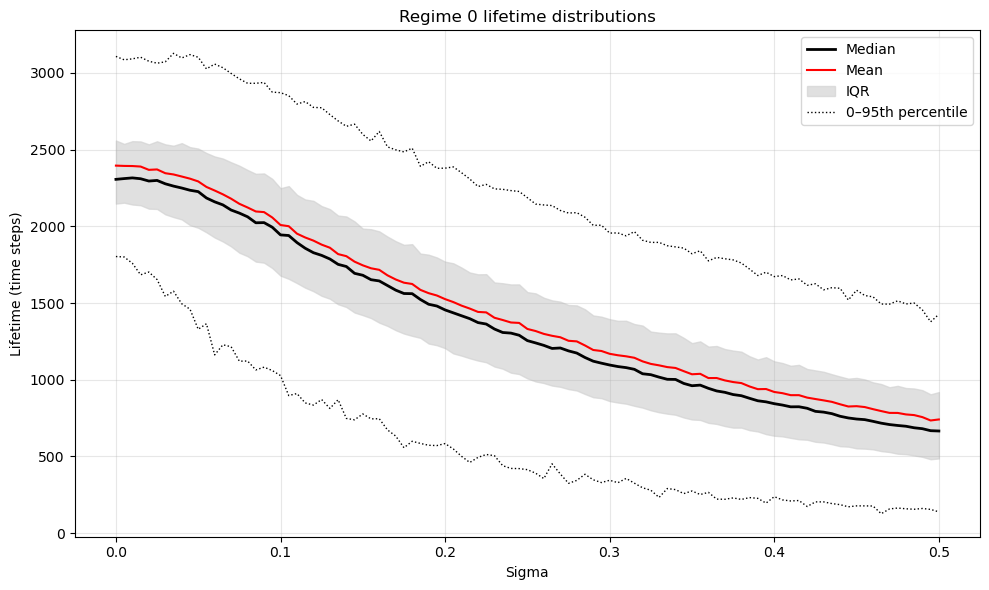

In [12]:
fig, ax = plot_lifetime_distributions_lines(
    {0: escape_times_per_sigma}, regime=0, logx=False)

# TO Methods

In [126]:
subsample_idx = np.linspace(0, states.shape[0]/10.01, int(1e4), dtype=int)
det_traj = states[subsample_idx, 0, :]

In [141]:
# 31 min
from scipy import sparse
import pickle
t_escape_dict = {}
for sig in np.linspace(0.0, 1e-1, 101, dtype=np.float32):
    eps = 2 * sig**2
    print(f"Processing epsilon = {eps:.6f}")
    # Compute diffusion matrix for this epsilon
    DMM, A = diffusion_maps_matrix(det_traj, eps)  # row-stochastic

    # Build one-step deterministic + diffusion transfer operator
    L = sparse.vstack(
        [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')

    # Compute expected escape times for the blocking set
    t_escape = expected_escape_times_from_TO(
        L, np.linalg.norm(det_traj, axis=1) < 1.0)

    # Store
    t_escape_dict[eps] = t_escape

with open('./Toy3dData/datadetTOesc.pkl', 'wb') as f:
    pickle.dump(t_escape_dict, f)

Processing epsilon = 0.000000
Processing epsilon = 0.000002
Processing epsilon = 0.000008
Processing epsilon = 0.000018
Processing epsilon = 0.000032
Processing epsilon = 0.000050
Processing epsilon = 0.000072
Processing epsilon = 0.000098
Processing epsilon = 0.000128
Processing epsilon = 0.000162
Processing epsilon = 0.000200
Processing epsilon = 0.000242
Processing epsilon = 0.000288
Processing epsilon = 0.000338
Processing epsilon = 0.000392
Processing epsilon = 0.000450
Processing epsilon = 0.000512
Processing epsilon = 0.000578
Processing epsilon = 0.000648
Processing epsilon = 0.000722
Processing epsilon = 0.000800
Processing epsilon = 0.000882
Processing epsilon = 0.000968
Processing epsilon = 0.001058
Processing epsilon = 0.001152
Processing epsilon = 0.001250
Processing epsilon = 0.001352
Processing epsilon = 0.001458
Processing epsilon = 0.001568
Processing epsilon = 0.001682
Processing epsilon = 0.001800
Processing epsilon = 0.001922
Processing epsilon = 0.002048
Processing

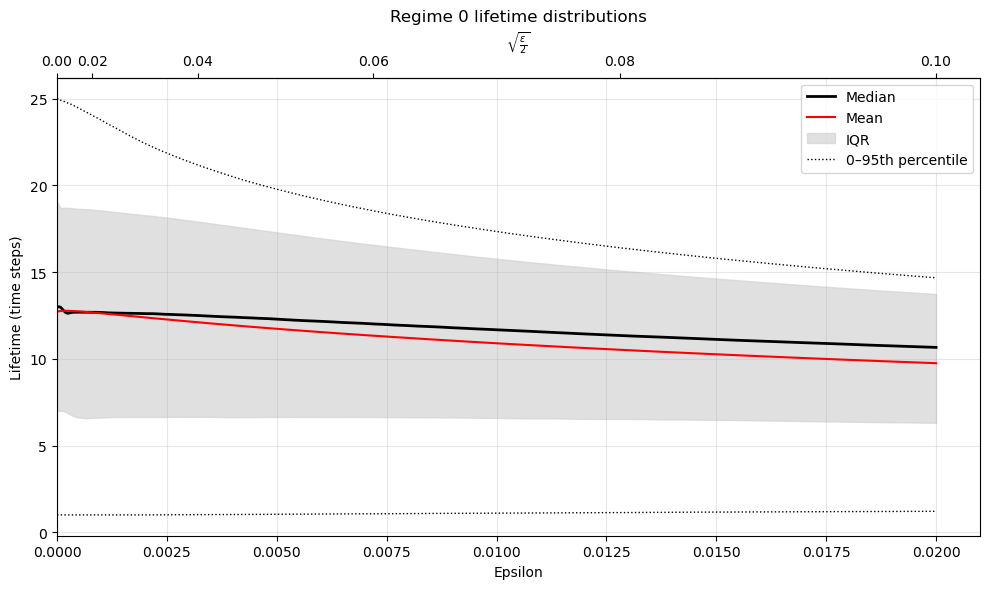

In [142]:
with open('./Toy3dData/datadetTOesc.pkl', 'rb') as f:
    t_escape_dict = pickle.load(f)
fig, ax = plot_lifetime_distributions_lines(
    {0: t_escape_dict}, regime=0, logx=False, xlabel="Epsilon")
fig, ax = add_scaled_top_axis(fig, ax, sorted(t_escape_dict.keys()))

## Go into detail for sigma=0 (det)

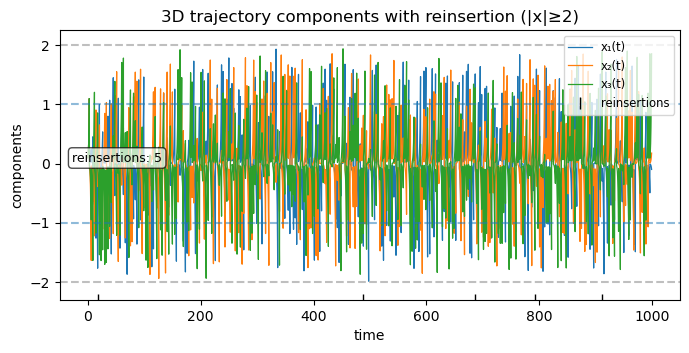

In [128]:
reset_times_per_path = [
    times[subsample_idx][np.linalg.norm(det_traj, axis=1) > 2.0]
    for j in range(det_traj.shape[1])
]
fig, ax = plt.subplots(figsize=(8, 3.5))

plot_trajectory_with_reinsertions_3d(
    ax, times[subsample_idx], det_traj, reset_times_per_path[0])
plt.show()

In [127]:
np.linalg.norm(det_traj[-1, :])

np.float32(1.8668168)

In [129]:
DMM, A = diffusion_maps_matrix(det_traj, 0.0)  # row-stochastic

# Build one-step deterministic + diffusion transfer operator
L = sparse.vstack(
    [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')

# Compute expected escape times for the blocking set
t_escape = expected_escape_times_from_TO(
    L, np.linalg.norm(det_traj, axis=1) < 1.0)

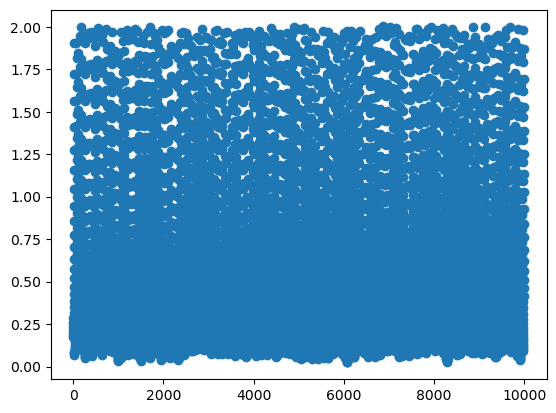

In [130]:
plt.scatter(np.arange(det_traj.shape[0]), np.linalg.norm(det_traj, axis=1))

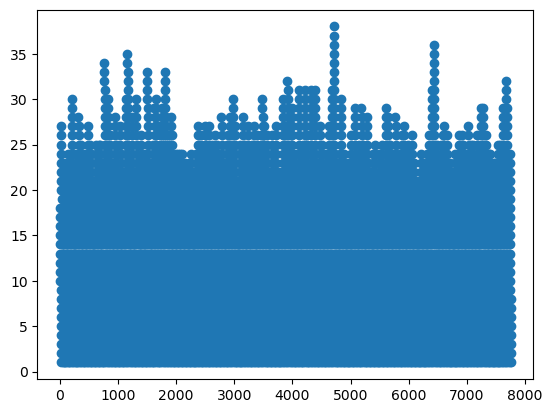

In [131]:
plt.scatter(np.arange(t_escape.shape[0]), t_escape)

<Axes: >

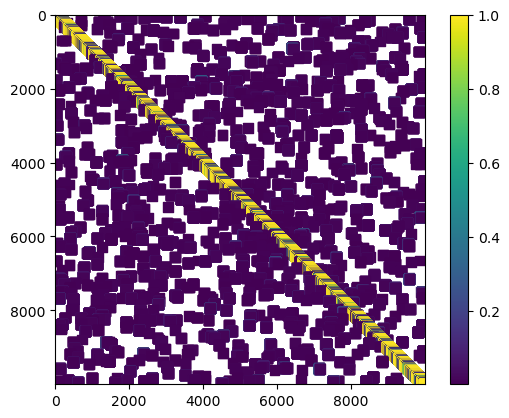

In [134]:
DMM, A = diffusion_maps_matrix(det_traj, 1e-4)
spy_col(DMM)

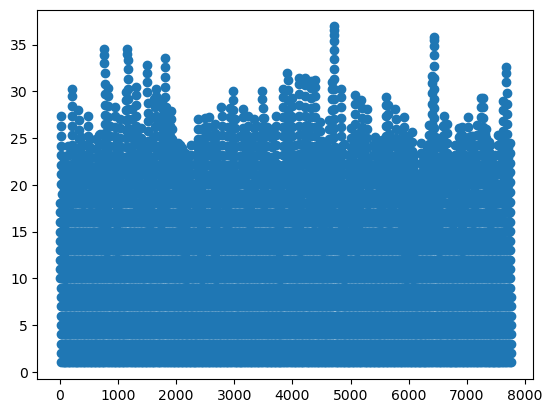

In [135]:
L = sparse.vstack(
    [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')
t_escape = expected_escape_times_from_TO(
    L, np.linalg.norm(det_traj, axis=1) < 1.0)
plt.scatter(np.arange(t_escape.shape[0]), t_escape)

## Is the ball sampled homogeneously?

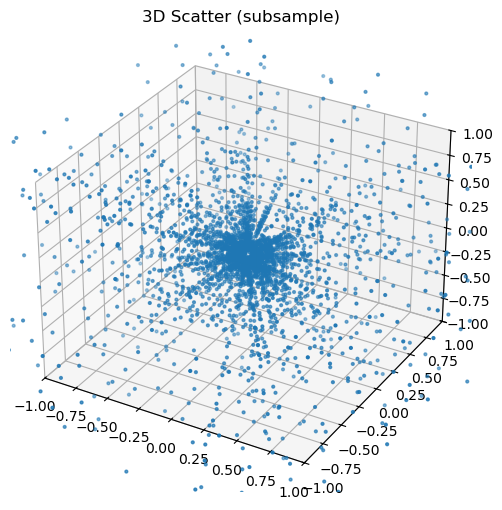

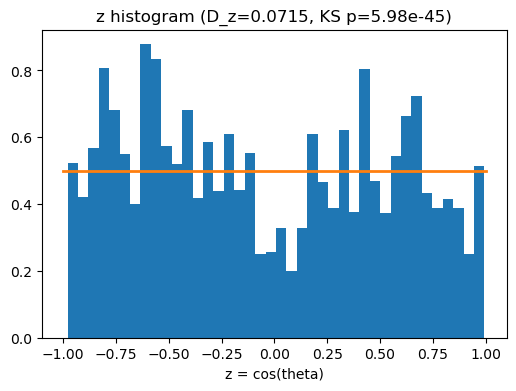

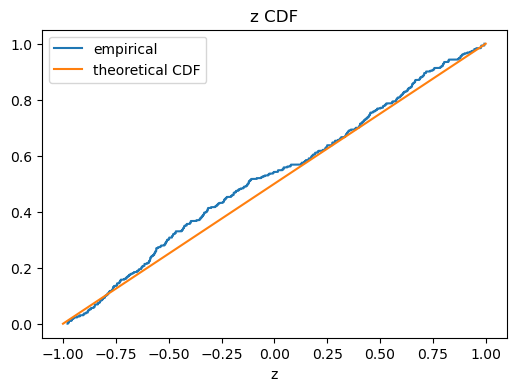

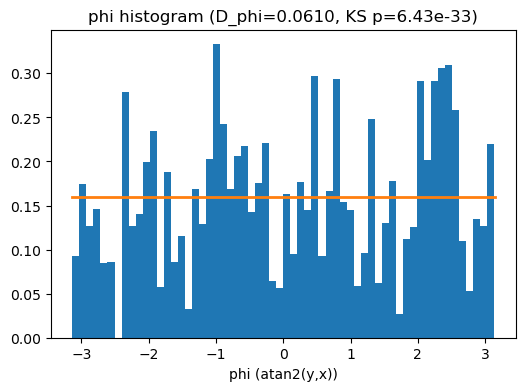

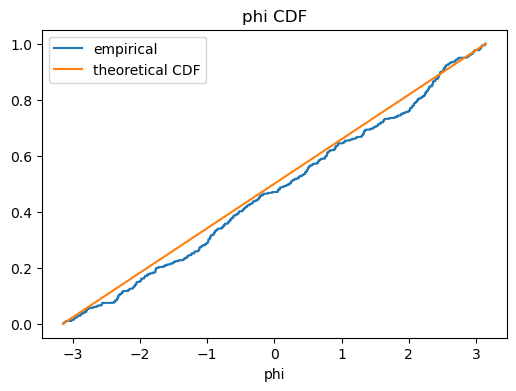

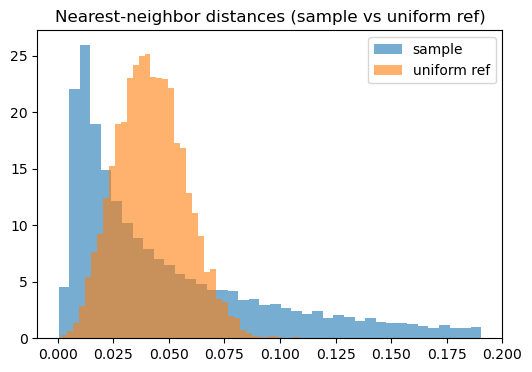

,n_points,frac_outside,D_z,ks_stat_z,ks_pvalue_z,D_phi,ks_stat_phi,ks_pvalue_phi,mean_nn,mean_nn_ref
0,10000,0.2238,0.07154,0.07154,5.983328e-45,0.061021,0.061121,6.428850e-33,0.048598,0.042009


In [124]:
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from scipy import stats
import math


def sample_uniform_ball(n, random_state=None):
    rng = np.random.default_rng(random_state)
    vec = rng.normal(size=(n, 3))
    norms = np.linalg.norm(vec, axis=1, keepdims=True)
    directions = vec / norms
    u = rng.random(n)
    r = u ** (1/3)
    pts = directions * r.reshape(-1, 1)
    return pts


def analyze_points_angles_only(pts, reference_samples=2000, show_plots=True):
    """
    Angular/isotropy checks for pts (N,3). Returns a pandas DataFrame summary.
    Keeps:
      - outside-ball fraction
      - distribution of z = cos(theta) (should be uniform on [-1,1])
      - distribution of phi = atan2(y,x) (should be uniform on [-pi,pi))
      - KS tests for both z and phi (phi tested against uniform on [-pi,2pi] loc/scale)
      - nearest-neighbor distances compared to uniform-in-ball reference
    """
    pts = np.asarray(pts, dtype=float)
    if pts.ndim != 2 or pts.shape[1] != 3:
        raise ValueError("pts must be an (N,3) array")
    n = pts.shape[0]

    # Basic outside-ball check
    radii = np.linalg.norm(pts, axis=1)
    outside = np.sum(radii > 1)
    frac_outside = outside / n

    # Unit directions
    norms = np.linalg.norm(pts, axis=1, keepdims=True)
    norms[norms == 0] = 1e-12
    unit_dirs = pts / norms

    # z = cos(theta), should be uniform on [-1,1]
    zs = unit_dirs[:, 2]
    sorted_z = np.sort(zs)
    emp_cdf_z = np.arange(1, n+1) / n
    theo_cdf_z = (sorted_z + 1) / 2.0
    D_z = np.max(np.abs(emp_cdf_z - theo_cdf_z))

    # KS test for z (mapped to uniform via identity on [-1,1])
    ks_stat_z, ks_pvalue_z = stats.kstest(
        zs, 'uniform', args=(-1, 2))  # loc=-1, scale=2

    # Azimuth phi = atan2(y,x), should be uniform on [-pi, pi)
    phi = np.arctan2(pts[:, 1], pts[:, 0])  # in [-pi, pi]
    # Sort and CDF
    sorted_phi = np.sort(phi)
    emp_cdf_phi = np.arange(1, n+1) / n
    theo_cdf_phi = (sorted_phi + np.pi) / (2 * np.pi)
    D_phi = np.max(np.abs(emp_cdf_phi - theo_cdf_phi))

    # KS test for phi by testing against uniform(-pi, 2*pi) via loc=-pi scale=2*pi
    ks_stat_phi, ks_pvalue_phi = stats.kstest(
        phi, 'uniform', args=(-math.pi, 2*math.pi))

    # Nearest-neighbor distances (O(n^2); ok for moderate n)
    diff = pts.reshape(n, 1, 3) - pts.reshape(1, n, 3)
    dists = np.linalg.norm(diff, axis=2)
    np.fill_diagonal(dists, np.inf)
    nn = dists.min(axis=1)
    mean_nn = nn.mean()

    # Reference NN distribution from uniform-in-ball sample
    ref_pts = sample_uniform_ball(reference_samples, random_state=0)
    nr = reference_samples
    diff_ref = ref_pts.reshape(nr, 1, 3) - ref_pts.reshape(1, nr, 3)
    dists_ref = np.linalg.norm(diff_ref, axis=2)
    np.fill_diagonal(dists_ref, np.inf)
    nn_ref = dists_ref.min(axis=1)
    mean_nn_ref = nn_ref.mean()

    summary = pd.DataFrame({
        'n_points': [n],
        'frac_outside': [float(frac_outside)],
        'D_z': [float(D_z)],
        'ks_stat_z': [float(ks_stat_z)],
        'ks_pvalue_z': [float(ks_pvalue_z)],
        'D_phi': [float(D_phi)],
        'ks_stat_phi': [float(ks_stat_phi)],
        'ks_pvalue_phi': [float(ks_pvalue_phi)],
        'mean_nn': [float(mean_nn)],
        'mean_nn_ref': [float(mean_nn_ref)]
    })

    if show_plots:
        # 3D scatter (subsample for plotting if large)
        subs = pts if n <= 3000 else pts[np.random.choice(
            n, 3000, replace=False)]
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(subs[:, 0], subs[:, 1], subs[:, 2], s=4)
        ax.set_title('3D Scatter (subsample)')
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_zlim(-1, 1)
        plt.show()

        # z histogram + theoretical line
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(zs, bins=40, density=True)
        zgrid = np.linspace(-1, 1, 200)
        ax.plot(zgrid, 0.5 * np.ones_like(zgrid), linewidth=2)
        ax.set_xlabel('z = cos(theta)')
        ax.set_title(f'z histogram (D_z={D_z:.4f}, KS p={ks_pvalue_z:.3g})')
        plt.show()

        # z CDF
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.step(sorted_z, emp_cdf_z, where='post', label='empirical')
        ax.plot(zgrid, (zgrid+1)/2, label='theoretical CDF')
        ax.set_xlabel('z')
        ax.set_title('z CDF')
        ax.legend()
        plt.show()

        # phi histogram + theoretical (flat) line
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(phi, bins=60, density=True)
        phi_grid = np.linspace(-math.pi, math.pi, 200)
        ax.plot(phi_grid, (1/(2*math.pi)) *
                np.ones_like(phi_grid), linewidth=2)
        ax.set_xlabel('phi (atan2(y,x))')
        ax.set_title(
            f'phi histogram (D_phi={D_phi:.4f}, KS p={ks_pvalue_phi:.3g})')
        plt.show()

        # phi CDF
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.step(sorted_phi, emp_cdf_phi, where='post', label='empirical')
        ax.plot(phi_grid, (phi_grid + math.pi) /
                (2*math.pi), label='theoretical CDF')
        ax.set_xlabel('phi')
        ax.set_title('phi CDF')
        ax.legend()
        plt.show()

        # NN histogram vs reference
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(nn, bins=40, density=True, alpha=0.6, label='sample')
        ax.hist(nn_ref, bins=40, density=True, alpha=0.6, label='uniform ref')
        ax.legend()
        ax.set_title('Nearest-neighbor distances (sample vs uniform ref)')
        plt.show()

    return summary

# -------------------------
# Example call (replace det_traj with your numpy array variable)
# summary = analyze_points_angles_only(det_traj, reference_samples=det_traj.shape[0], show_plots=True)
# display(summary)


# If your array is named `det_traj`, uncomment below to run immediately:
summary = analyze_points_angles_only(
    det_traj, reference_samples=det_traj.shape[0], show_plots=True)
display(summary)